In [1]:
import pandas as pd
from pathlib import Path
import copy

import matplotlib.pyplot as plt
FS = 15
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 
                                   'Bitstream Vera Sans', 'sans-serif']
plt.rcParams.update({'font.size': FS})

import numpy as np
import torch
from tqdm import tqdm
import pickle

from mist.utils.plot_utils import *
from rdkit import Chem
from rdkit.Chem import Draw, MolFromSmiles
from rdkit.Chem import rdFingerprintGenerator
from rdkit.DataStructs import TanimotoSimilarity
from rdkit.DataStructs.cDataStructs import ExplicitBitVect

import mist.utils as utils
import mist.subformulae.assign_subformulae as assign_subformulae
import mist.models.base as base
import mist.data.datasets as datasets
import mist.data.featurizers as featurizers
import mist.data.data as data

/root/anaconda3/envs/ms-gen/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-03 13:05:45,132	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-07-03 13:05:45,337	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
def numpy_to_rdkit_bitvec(arr_row):
    bitvec = ExplicitBitVect(len(arr_row))
    for i, bit in enumerate(arr_row):
        if bit == 1:
            bitvec.SetBit(i)
    return bitvec


In [3]:
# Make sure to predownload the pretrained models by following quickstart/
fp_ckpt="../pretrained_models/mist_fp_canopus_pretrain.ckpt"
contrast_ckpt="../pretrained_models/mist_contrastive_canopus_pretrain.ckpt"

res_dir = "../results/neims_gecko+/"
mgf_input = "../data/neims/gecko_EIMS_spectra/mist_inputs/neims_gecko+_spectra_all.mgf"
labels = "../data/neims/gecko_EIMS_spectra/mist_inputs/labels.tsv"
# smiles_input = "../data/neims/gecko_EIMS_spectra/mist_inputs/neims_gecko_lookup_smiles_all.txt"

res_dir = Path(res_dir)
res_dir.mkdir(exist_ok=True)


In [4]:

subform_dir=res_dir/"subforms"
subform_dir.mkdir(exist_ok=True,parents=True)

assign_subformulae.assign_subforms_chunked2(
    spec_files=mgf_input,
    labels_file=labels,
    output_dir=subform_dir,
    mass_diff_thresh=20,
    max_formulae=50,
    num_workers=16,
    feature_id="TITLE",
    debug=False,
    chunk_size=10_000
)

650246it [00:53, 12069.74it/s]


There are 325123 spec-cand pairs in the label file


Processing chunks: 100%|██████████| 33/33 [22:17<00:00, 40.53s/it]


In [5]:
raise Exception

Exception: 

In [ ]:
fp_save_dir = res_dir / "model_predictions"
fp_save_dir.mkdir(exist_ok=True, parents=True)

fp_model = torch.load(fp_ckpt, map_location=torch.device("cpu"))

main_hparams = fp_model["hyper_parameters"]
kwargs = copy.deepcopy(main_hparams)
for key, val in kwargs.items():
    print(key, val)

fp_names ['morgan4096']
binarization_thresh 0.5
loss_fn cosine
magma_aux_loss True
iterative_preds growing
iterative_loss_weight 0.4
shuffle_train False
magma_loss_lambda 8.0
form_embedder pos-cos
debug False
seed 1
save_dir results/canopus_fp_mist/split_0
magma_folder data/paired_spectra/canopus_train/magma_outputs/magma_tsv/
subform_folder data/paired_spectra/canopus_train/subformulae/subformulae_default/
labels_file data/paired_spectra/canopus_train/labels.tsv
spec_folder data/paired_spectra/canopus_train/spec_files/
split_file data/paired_spectra/canopus_train/splits/canopus_hplus_100_0.tsv
augment_data True
augment_prob 0.5
remove_weights exp
inten_transform float
inten_prob 0.1
remove_prob 0.5
forward_labels data/paired_spectra/canopus_train/aug_iceberg_canopus_train/biomols_filtered_smiles_canopus_train_labels.tsv
forward_aug_folder data/paired_spectra/canopus_train/aug_iceberg_canopus_train/canopus_hplus_100_0/subforms/
frac_orig 0.6
learning_rate 0.00077
weight_decay 1e-07
lr_

In [ ]:
kwargs['device'] = "cpu"
kwargs['num_workers'] = 0
kwargs['subform_folder'] = subform_dir
kwargs['labels_file'] = labels

device = torch.device("cpu")
model = base.build_model(**kwargs)

model.load_state_dict(fp_model["state_dict"])
model = model.to(device)
model = model.eval()

kwargs["spec_features"] = model.spec_features(mode="test")
kwargs['mol_features'] = "none"
kwargs['allow_none_smiles'] = True

paired_featurizer = featurizers.get_paired_featurizer(**kwargs)

In [ ]:
# Ignore errors; we're just using this to get the featurizer
spectra_mol_pairs = datasets.get_paired_spectra(**kwargs)
spectra_mol_pairs = list(zip(*spectra_mol_pairs))
test_dataset = datasets.SpectraMolDataset(
    spectra_mol_list=spectra_mol_pairs, featurizer=paired_featurizer, **kwargs
)
output_preds = (
    model.encode_all_spectras(test_dataset, no_grad=True, **kwargs).cpu().numpy()
)
output_names = test_dataset.get_spectra_names()

10000it [00:00, 219668.37it/s]
10000it [00:00, 394160.75it/s]
10000it [00:00, 5121250.31it/s]


In [ ]:
arr = output_preds >= 0.5
arr = arr.astype(np.int8)
fp_name = kwargs['fp_names'][0]
#fp_file_out = f'../data/neims/{fp_name}.txt'
#np.savetxt(fp_file_out, arr, fmt="%d")

In [ ]:
smiles = pd.read_csv('../data/neims/gecko_EIMS_spectra/mist_inputs/neims_gecko_smiles_10000.csv')['SMILES'].values
smiles

array(['C1(=O)C([N+](=O)[O-])(OO)C(O[N+](=O)[O-])(C(OO))OOC(=O)C1',
       'CC(=O)C(O[N+](=O)[O-])C(C)(C)C(O[N+](=O)[O-])(C)C(=O)(O)',
       'C1(=O)OC1C(OO)(C)C(=O)(OO)', ...,
       'C(=O)(OO)C([N+](=O)[O-])(O[N+](=O)[O-])C(C(=O))OOC(=O)C(=O)',
       'C(=O)(OO)C(=O)C(OO)C([N+](=O)[O-])(C(=O)(O))OOC(=O)',
       'CC(=O)C(OO)CC(=O)C(O)CC(O)'], dtype=object)

In [ ]:
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=4096)
morgan_fps = []
for smi in smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        morgan_fps.append(None)  # handle invalid smiles
        continue
    fp = fpgen.GetFingerprint(mol)  # ExplicitBitVect
    morgan_fps.append(fp)

In [ ]:
predicted_fps = [numpy_to_rdkit_bitvec(row) for row in arr]

In [ ]:
similarities = []
for pred_fp, true_fp in zip(predicted_fps, morgan_fps):
    if pred_fp is None or true_fp is None:
        similarities.append(None)  # skip invalid
    else:
        sim = TanimotoSimilarity(pred_fp, true_fp)
        similarities.append(sim)

In [ ]:
valid_sims = [sim for sim in similarities if sim is not None]
print(f'{len(valid_sims)} valid similarities')
print(f"Mean Tanimoto similarity: {np.mean(valid_sims):.3f}")
print(f"Median Tanimoto similarity: {np.median(valid_sims):.3f}")

10000 valid similarities
Mean Tanimoto similarity: 0.164
Median Tanimoto similarity: 0.167


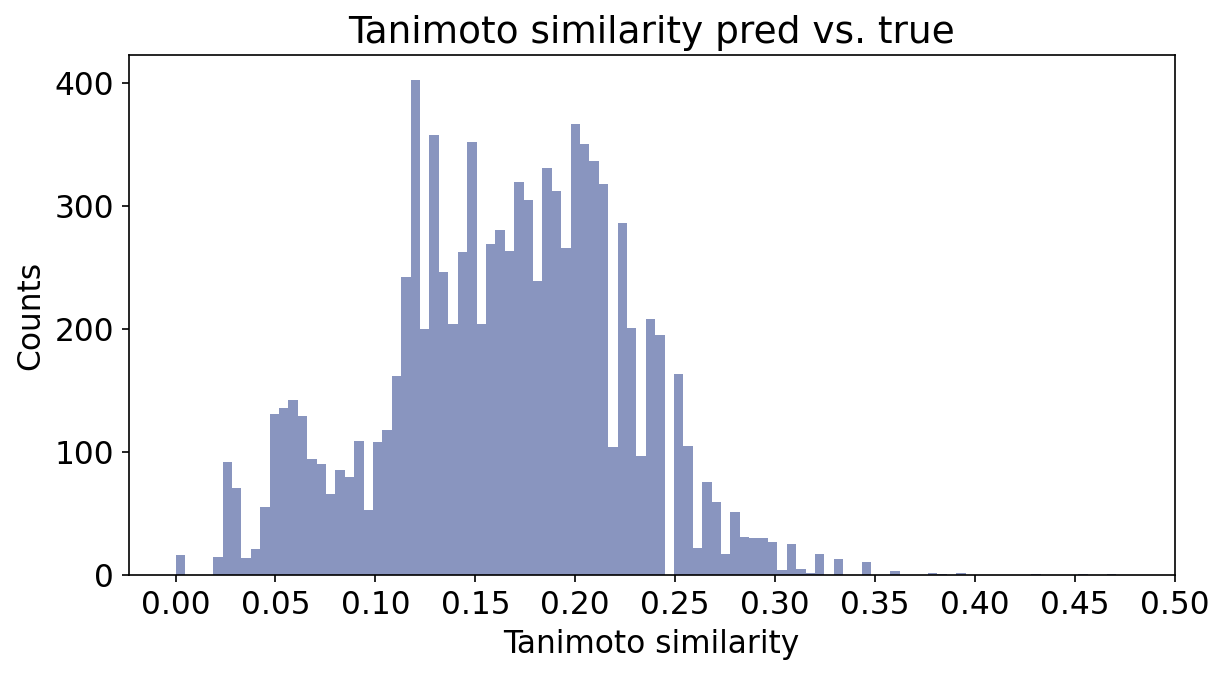

In [ ]:
plt.figure(figsize=(9,4.5), dpi=150)
plt.hist(valid_sims, bins=100, color='#8995BF')
plt.title('Tanimoto similarity pred vs. true')
plt.xlabel('Tanimoto similarity')
plt.ylabel('Counts')
plt.xticks(np.linspace(0, 0.5, 11))
plt.show()

In [ ]:
# Make sure to predownload the pretrained models by following quickstart/
fp_ckpt="../pretrained_models/mist_fp_canopus_pretrain.ckpt"
contrast_ckpt="../pretrained_models/mist_contrastive_canopus_pretrain.ckpt"

res_dir = "../results/neims_canopus/"
mgf_input = '../data/paired_spectra/canopus_train/exp_canopus_train/mist_inputs/exp_canopus_all_test_spectra.mgf'
labels = '../data/paired_spectra/canopus_train/exp_canopus_train/mist_inputs/exp_canopus_all_test_labels.tsv'

res_dir = Path(res_dir)
res_dir.mkdir(exist_ok=True)


In [ ]:

subform_dir=res_dir/"subforms"
subform_dir.mkdir(exist_ok=True,parents=True)

assign_subformulae.assign_subforms(
    spec_files=mgf_input,
    labels_file=labels,
    output_dir=subform_dir,
    mass_diff_thresh=20,
    max_formulae=50,
    num_workers=32,
    feature_id="_FILE",
    debug=False
)

0it [00:00, ?it/s]

4412it [00:02, 1681.20it/s]


There are 2206 spec-cand pairs this spec files


2206it [00:00, 4982.23it/s]


In [ ]:
fp_save_dir = res_dir / "model_predictions"
fp_save_dir.mkdir(exist_ok=True, parents=True)

fp_model = torch.load(fp_ckpt, map_location=torch.device("cpu"))

main_hparams = fp_model["hyper_parameters"]
kwargs = copy.deepcopy(main_hparams)

In [ ]:
kwargs['device'] = "cpu"
kwargs['num_workers'] = 0
kwargs['subform_folder'] = subform_dir
kwargs['labels_file'] = labels

device = torch.device("cpu")
model = base.build_model(**kwargs)

model.load_state_dict(fp_model["state_dict"])
model = model.to(device)
model = model.eval()

kwargs["spec_features"] = model.spec_features(mode="test")
kwargs['mol_features'] = "none"
kwargs['allow_none_smiles'] = True

paired_featurizer = featurizers.get_paired_featurizer(**kwargs)

In [ ]:
# Ignore errors; we're just using this to get the featurizer
spectra_mol_pairs = datasets.get_paired_spectra(**kwargs)
spectra_mol_pairs = list(zip(*spectra_mol_pairs))
test_dataset = datasets.SpectraMolDataset(
    spectra_mol_list=spectra_mol_pairs, featurizer=paired_featurizer, **kwargs
)
output_preds = (
    model.encode_all_spectras(test_dataset, no_grad=True, **kwargs).cpu().numpy()
)
output_names = test_dataset.get_spectra_names()

2206it [00:00, 175665.15it/s]
2206it [00:00, 11813.39it/s]
2206it [00:00, 6571473.45it/s]


In [ ]:
arr = output_preds >= 0.5
arr = arr.astype(np.int8)
fp_name = kwargs['fp_names'][0]
#fp_file_out = f'../data/neims/canopus_{fp_name}.txt'
#np.savetxt(fp_file_out, arr, fmt="%d")

In [ ]:
smiles = pd.read_csv('../data/paired_spectra/canopus_train/exp_canopus_train/mist_inputs/exp_canopus_all_test_smiles.csv')['SMILES'].values
smiles

array(['CCC(=O)CCCCCC1NC(=O)C2CCCCN2C(=O)C(Cc2ccccc2)NC(=O)C(C)NC1=O',
       'CCCCCCCCCCCCCC(=O)NC(C)(C)C(=O)N1CCCC1C(=O)NC(CC(C)C)C(=O)NC(C(=O)NC(CCC(N)=O)C(=O)NC(CO)CC(C)C)C(C)C',
       'CC(C)CC1NC(=O)C(NC(=O)c2ncccc2O)C(C)OC(=O)C(c2ccccc2)N(C)C(=O)C(C)NC(=O)C(C(C)C(C)C)N(C)C(=O)CN(C)C(=O)C2CC(O)CN2C1=O',
       ..., 'COc1cc(OC)c(C(=O)C=Cc2ccc(OC)c(OC)c2)c(OC)c1',
       'O=C1NCCc2c1[nH]c1c(Cl)cccc21',
       'COc1cc(OC)c2c(c1)OC(c1ccc(O)cc1)CC2=O'], dtype=object)

In [ ]:
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=4096)
morgan_fps = []
for smi in smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        morgan_fps.append(None)  # handle invalid smiles
        continue
    fp = fpgen.GetFingerprint(mol)  # ExplicitBitVect
    morgan_fps.append(fp)
predicted_fps = [numpy_to_rdkit_bitvec(row) for row in arr]
similarities = []
for pred_fp, true_fp in zip(predicted_fps, morgan_fps):
    if pred_fp is None or true_fp is None:
        similarities.append(None)  # skip invalid
    else:
        sim = TanimotoSimilarity(pred_fp, true_fp)
        similarities.append(sim)

In [ ]:
valid_sims = [sim for sim in similarities if sim is not None]
print(f'{len(valid_sims)} valid similarities')
print(f"Mean Tanimoto similarity: {np.mean(valid_sims):.3f}")
print(f"Median Tanimoto similarity: {np.median(valid_sims):.3f}")

2206 valid similarities
Mean Tanimoto similarity: 0.684
Median Tanimoto similarity: 0.767


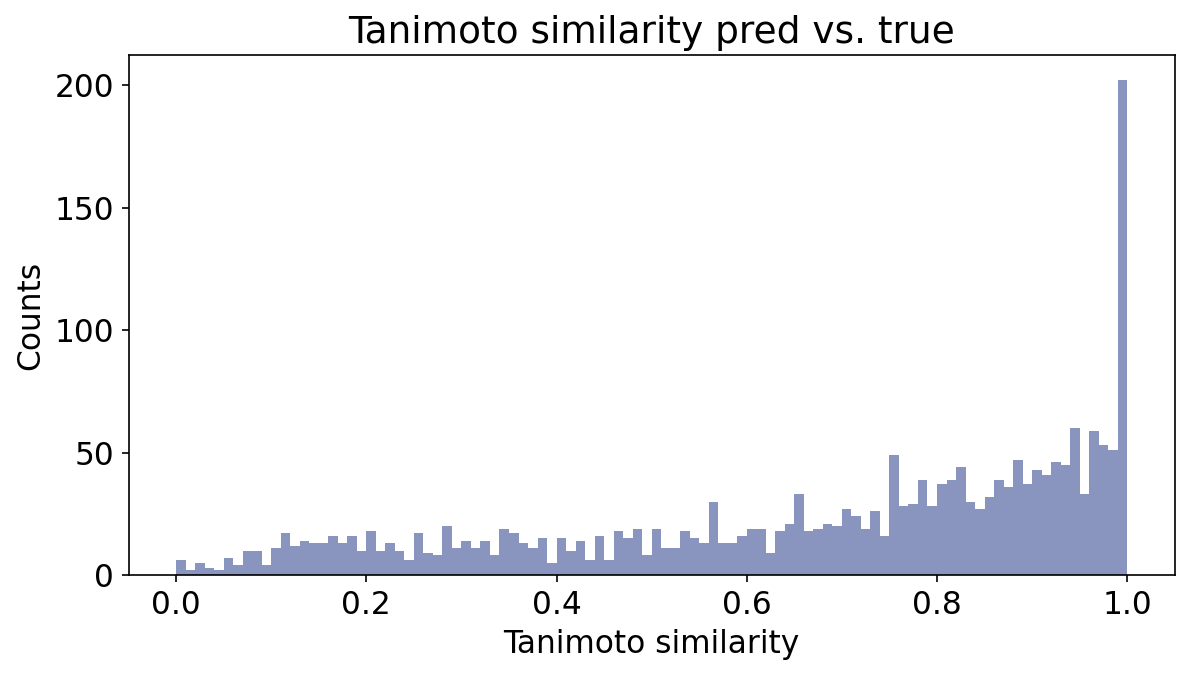

In [ ]:
plt.figure(figsize=(9,4.5), dpi=150)
plt.hist(valid_sims, bins=100, color='#8995BF')
plt.title('Tanimoto similarity pred vs. true')
plt.xlabel('Tanimoto similarity')
plt.ylabel('Counts')
#plt.xticks(np.linspace(0, 0.5, 11))
plt.show()

## Exp franklin

In [ ]:
# Make sure to predownload the pretrained models by following quickstart/
fp_ckpt="../pretrained_models/mist_fp_canopus_pretrain.ckpt"
contrast_ckpt="../pretrained_models/mist_contrastive_canopus_pretrain.ckpt"

res_dir = "../results/exp_franklin/"
mgf_input = "../data/neims/Franklin_dataset/mist_inputs/exp_franklin_spectra.mgf"
labels = "../data/neims/Franklin_dataset/mist_inputs/exp_franklin_labels.tsv"

res_dir = Path(res_dir)
res_dir.mkdir(exist_ok=True)


In [ ]:

subform_dir=res_dir/"subforms"
subform_dir.mkdir(exist_ok=True,parents=True)

assign_subformulae.assign_subforms(
    spec_files=mgf_input,
    labels_file=labels,
    output_dir=subform_dir,
    mass_diff_thresh=20,
    max_formulae=50,
    num_workers=32,
    feature_id="FEATURE_ID",
    debug=False
)

138it [00:00, 18146.34it/s]

There are 69 spec-cand pairs this spec files



69it [00:00, 7247.68it/s]


In [ ]:
fp_save_dir = res_dir / "model_predictions"
fp_save_dir.mkdir(exist_ok=True, parents=True)

fp_model = torch.load(fp_ckpt, map_location=torch.device("cpu"))

main_hparams = fp_model["hyper_parameters"]
kwargs = copy.deepcopy(main_hparams)

In [ ]:
kwargs['device'] = "cpu"
kwargs['num_workers'] = 0
kwargs['subform_folder'] = subform_dir
kwargs['labels_file'] = labels

device = torch.device("cpu")
model = base.build_model(**kwargs)

model.load_state_dict(fp_model["state_dict"])
model = model.to(device)
model = model.eval()

kwargs["spec_features"] = model.spec_features(mode="test")
kwargs['mol_features'] = "none"
kwargs['allow_none_smiles'] = True

paired_featurizer = featurizers.get_paired_featurizer(**kwargs)

In [ ]:
# Ignore errors; we're just using this to get the featurizer
spectra_mol_pairs = datasets.get_paired_spectra(**kwargs)
spectra_mol_pairs = list(zip(*spectra_mol_pairs))
test_dataset = datasets.SpectraMolDataset(
    spectra_mol_list=spectra_mol_pairs, featurizer=paired_featurizer, **kwargs
)
output_preds = (
    model.encode_all_spectras(test_dataset, no_grad=True, **kwargs).cpu().numpy()
)
output_names = test_dataset.get_spectra_names()

69it [00:00, 229505.93it/s]
69it [00:00, 53248.75it/s]
69it [00:00, 1022639.49it/s]


In [ ]:
arr = output_preds >= 0.5
arr = arr.astype(np.int8)
fp_name = kwargs['fp_names'][0]

In [ ]:
smiles = pd.read_csv('../data/neims/Franklin_dataset/smiles.csv')['SMILES'].values

In [ ]:
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=4096)
morgan_fps = []
for smi in smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        morgan_fps.append(None)  # handle invalid smiles
        continue
    fp = fpgen.GetFingerprint(mol)  # ExplicitBitVect
    morgan_fps.append(fp)
predicted_fps = [numpy_to_rdkit_bitvec(row) for row in arr]
similarities = []
for pred_fp, true_fp in zip(predicted_fps, morgan_fps):
    if pred_fp is None or true_fp is None:
        similarities.append(None)  # skip invalid
    else:
        sim = TanimotoSimilarity(pred_fp, true_fp)
        similarities.append(sim)

In [ ]:
valid_sims = [sim for sim in similarities if sim is not None]
print(f'{len(valid_sims)} valid similarities')
print(f"Mean Tanimoto similarity: {np.mean(valid_sims):.3f}")
print(f"Median Tanimoto similarity: {np.median(valid_sims):.3f}")

69 valid similarities
Mean Tanimoto similarity: 0.178
Median Tanimoto similarity: 0.167


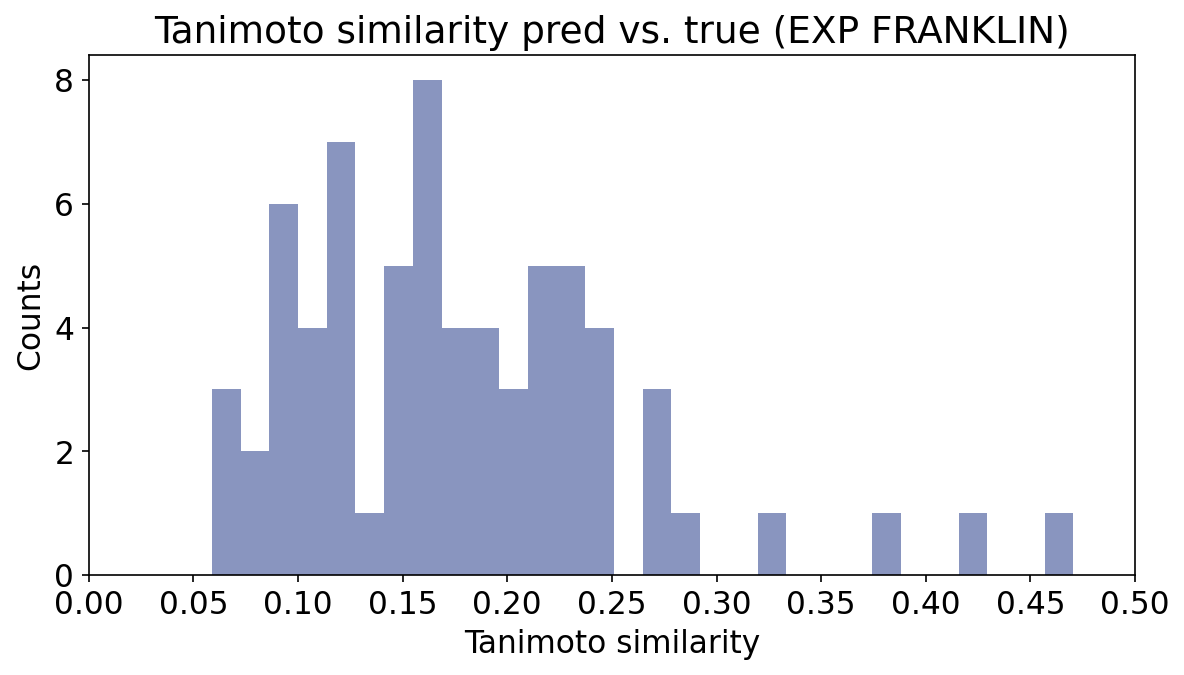

In [ ]:
plt.figure(figsize=(9,4.5), dpi=150)
plt.hist(valid_sims, bins=30, color='#8995BF')
plt.title('Tanimoto similarity pred vs. true (EXP FRANKLIN)')
plt.xlabel('Tanimoto similarity')
plt.ylabel('Counts')
plt.xticks(np.linspace(0, 0.5, 11))
plt.show()

## Neims Franklin

In [ ]:
# Make sure to predownload the pretrained models by following quickstart/
fp_ckpt="../pretrained_models/mist_fp_canopus_pretrain.ckpt"
contrast_ckpt="../pretrained_models/mist_contrastive_canopus_pretrain.ckpt"

res_dir = "../results/neims_franklin/"
mgf_input = "../data/neims/Franklin_dataset/mist_inputs/neims_franklin_spectra.mgf"
labels = "../data/neims/Franklin_dataset/mist_inputs/neims_franklin_labels.tsv"

res_dir = Path(res_dir)
res_dir.mkdir(exist_ok=True)


subform_dir=res_dir/"subforms"
subform_dir.mkdir(exist_ok=True,parents=True)

assign_subformulae.assign_subforms(
    spec_files=mgf_input,
    labels_file=labels,
    output_dir=subform_dir,
    mass_diff_thresh=20,
    max_formulae=50,
    num_workers=32,
    feature_id="FEATURE_ID",
    debug=False
)
fp_save_dir = res_dir / "model_predictions"
fp_save_dir.mkdir(exist_ok=True, parents=True)

fp_model = torch.load(fp_ckpt, map_location=torch.device("cpu"))

main_hparams = fp_model["hyper_parameters"]
kwargs = copy.deepcopy(main_hparams)

    

138it [00:00, 15402.18it/s]

There are 69 spec-cand pairs this spec files



69it [00:00, 7182.56it/s]


In [ ]:
kwargs['device'] = "cpu"
kwargs['num_workers'] = 0
kwargs['subform_folder'] = subform_dir
kwargs['labels_file'] = labels

device = torch.device("cpu")
model = base.build_model(**kwargs)

model.load_state_dict(fp_model["state_dict"])
model = model.to(device)
model = model.eval()

kwargs["spec_features"] = model.spec_features(mode="test")
kwargs['mol_features'] = "none"
kwargs['allow_none_smiles'] = True

paired_featurizer = featurizers.get_paired_featurizer(**kwargs)

# Ignore errors; we're just using this to get the featurizer
spectra_mol_pairs = datasets.get_paired_spectra(**kwargs)
spectra_mol_pairs = list(zip(*spectra_mol_pairs))
test_dataset = datasets.SpectraMolDataset(
    spectra_mol_list=spectra_mol_pairs, featurizer=paired_featurizer, **kwargs
)
output_preds = (
    model.encode_all_spectras(test_dataset, no_grad=True, **kwargs).cpu().numpy()
)
output_names = test_dataset.get_spectra_names()

arr = output_preds >= 0.5
arr = arr.astype(np.int8)
fp_name = kwargs['fp_names'][0]
smiles = pd.read_csv('../data/neims/Franklin_dataset/smiles.csv')['SMILES'].values

69it [00:00, 216621.99it/s]
69it [00:00, 84969.75it/s]
69it [00:00, 1539398.81it/s]


In [ ]:
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=4096)
morgan_fps = []
for smi in smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        morgan_fps.append(None)  # handle invalid smiles
        continue
    fp = fpgen.GetFingerprint(mol)  # ExplicitBitVect
    morgan_fps.append(fp)

predicted_fps = [numpy_to_rdkit_bitvec(row) for row in arr]

similarities = []
for pred_fp, true_fp in zip(predicted_fps, morgan_fps):
    if pred_fp is None or true_fp is None:
        similarities.append(None)  # skip invalid
    else:
        sim = TanimotoSimilarity(pred_fp, true_fp)
        similarities.append(sim)

In [ ]:
valid_sims = [sim for sim in similarities if sim is not None]
print(f'{len(valid_sims)} valid similarities')
print(f"Mean Tanimoto similarity: {np.mean(valid_sims):.3f}")
print(f"Median Tanimoto similarity: {np.median(valid_sims):.3f}")

69 valid similarities
Mean Tanimoto similarity: 0.174
Median Tanimoto similarity: 0.158


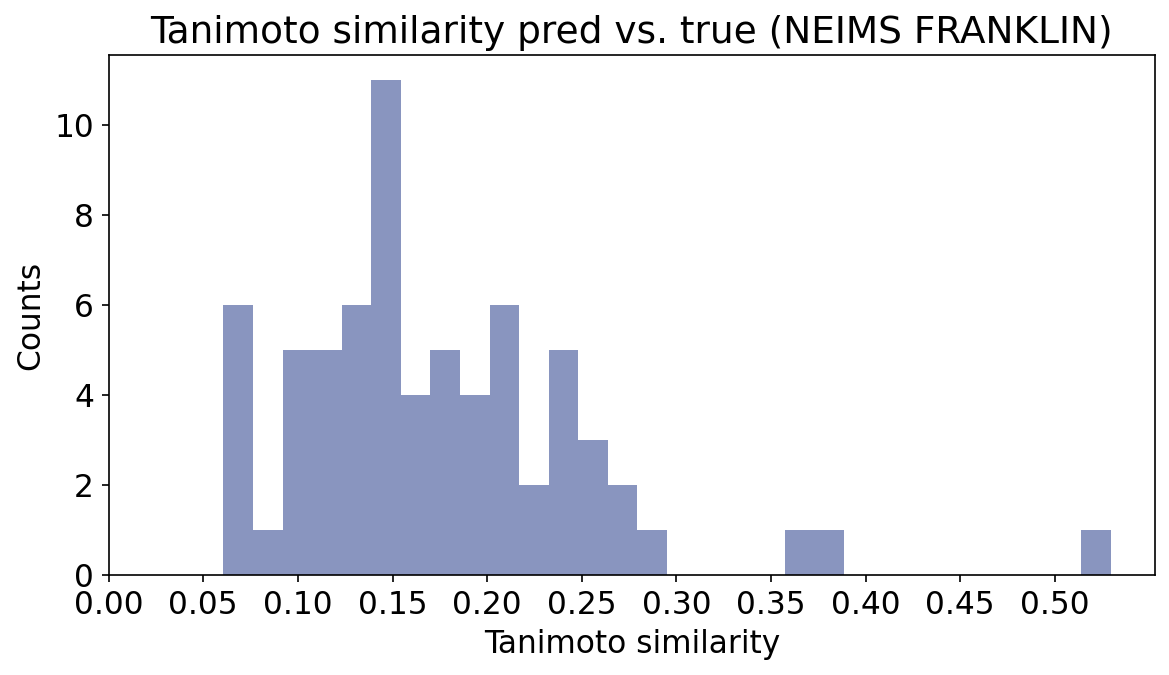

In [ ]:
plt.figure(figsize=(9,4.5), dpi=150)
plt.hist(valid_sims, bins=30, color='#8995BF')
plt.title('Tanimoto similarity pred vs. true (NEIMS FRANKLIN)')
plt.xlabel('Tanimoto similarity')
plt.ylabel('Counts')
plt.xticks(np.linspace(0, 0.5, 11))
plt.show()

## Canopus Neims

In [ ]:
# Make sure to predownload the pretrained models by following quickstart/
fp_ckpt="../pretrained_models/mist_fp_canopus_pretrain.ckpt"
contrast_ckpt="../pretrained_models/mist_contrastive_canopus_pretrain.ckpt"

res_dir = "../results/neims_canopus/"
mgf_input = "../data/neims/mist/mist_inputs/neims_canopus_spectra.mgf"
labels = "../data/neims/mist/mist_inputs/neims_canopus_labels.tsv"

res_dir = Path(res_dir)
res_dir.mkdir(exist_ok=True)
assert Path(res_dir).exists(); 
assert Path(mgf_input).is_file(); 
assert Path(labels).is_file()

subform_dir=res_dir/"subforms"
subform_dir.mkdir(exist_ok=True,parents=True)

assign_subformulae.assign_subforms(
    spec_files=mgf_input,
    labels_file=labels,
    output_dir=subform_dir,
    mass_diff_thresh=20,
    max_formulae=50,
    num_workers=32,
    feature_id="FEATURE_ID",
    debug=False
)
fp_save_dir = res_dir / "model_predictions"
fp_save_dir.mkdir(exist_ok=True, parents=True)

fp_model = torch.load(fp_ckpt, map_location=torch.device("cpu"))

main_hparams = fp_model["hyper_parameters"]
kwargs = copy.deepcopy(main_hparams)

    

4412it [00:00, 11850.55it/s]


There are 2206 spec-cand pairs this spec files


2206it [00:00, 5253.96it/s]


In [ ]:
kwargs['device'] = "cpu"
kwargs['num_workers'] = 0
kwargs['subform_folder'] = subform_dir
kwargs['labels_file'] = labels

device = torch.device("cpu")
model = base.build_model(**kwargs)

model.load_state_dict(fp_model["state_dict"])
model = model.to(device)
model = model.eval()

kwargs["spec_features"] = model.spec_features(mode="test")
kwargs['mol_features'] = "none"
kwargs['allow_none_smiles'] = True

paired_featurizer = featurizers.get_paired_featurizer(**kwargs)

# Ignore errors; we're just using this to get the featurizer
spectra_mol_pairs = datasets.get_paired_spectra(**kwargs)
spectra_mol_pairs = list(zip(*spectra_mol_pairs))
test_dataset = datasets.SpectraMolDataset(
    spectra_mol_list=spectra_mol_pairs, featurizer=paired_featurizer, **kwargs
)
output_preds = (
    model.encode_all_spectras(test_dataset, no_grad=True, **kwargs).cpu().numpy()
)
output_names = test_dataset.get_spectra_names()

arr = output_preds >= 0.5
arr = arr.astype(np.int8)
fp_name = kwargs['fp_names'][0]
smiles = pd.read_csv('../data/neims/mist/smiles_canopus.csv')['SMILES'].values

2206it [00:00, 216112.36it/s]
2206it [00:00, 136713.52it/s]
2206it [00:00, 4092275.38it/s]


In [ ]:
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=4096)
morgan_fps = []
for smi in smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        morgan_fps.append(None)  # handle invalid smiles
        continue
    fp = fpgen.GetFingerprint(mol)  # ExplicitBitVect
    morgan_fps.append(fp)

predicted_fps = [numpy_to_rdkit_bitvec(row) for row in arr]

similarities = []
for pred_fp, true_fp in zip(predicted_fps, morgan_fps):
    if pred_fp is None or true_fp is None:
        similarities.append(None)  # skip invalid
    else:
        sim = TanimotoSimilarity(pred_fp, true_fp)
        similarities.append(sim)

In [ ]:
valid_sims = [sim for sim in similarities if sim is not None]
print(f'{len(valid_sims)} valid similarities')
print(f"Mean Tanimoto similarity: {np.mean(valid_sims):.3f}")
print(f"Median Tanimoto similarity: {np.median(valid_sims):.3f}")

2206 valid similarities
Mean Tanimoto similarity: 0.149
Median Tanimoto similarity: 0.118


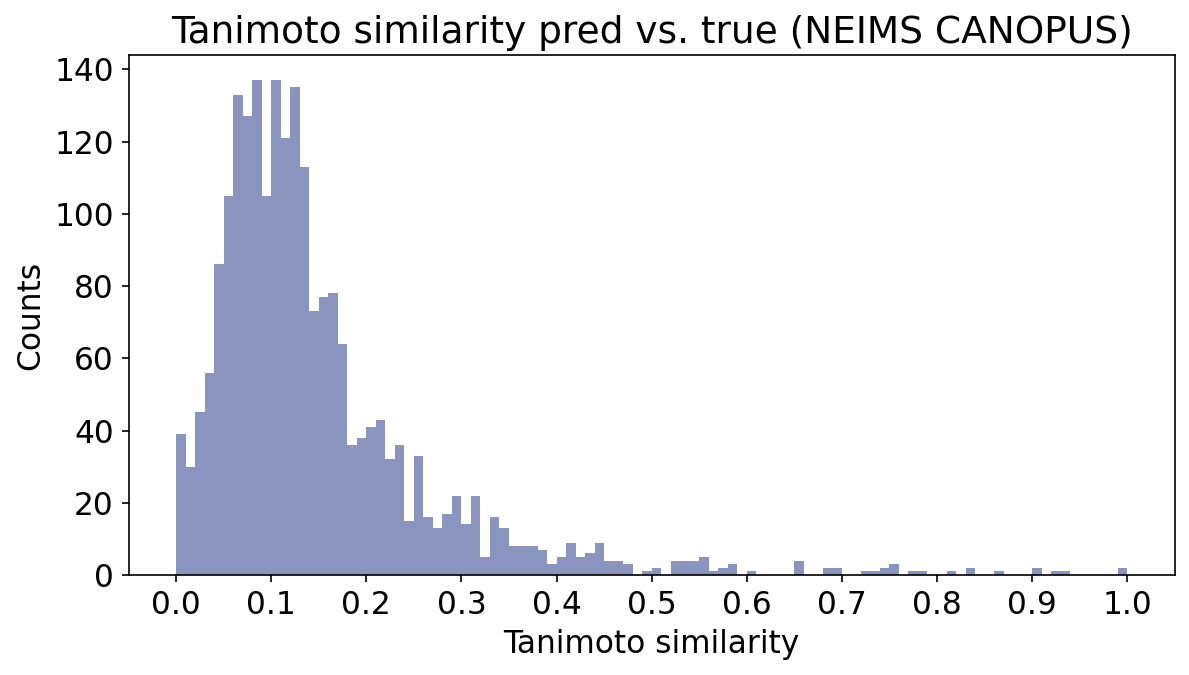

In [ ]:
plt.figure(figsize=(9,4.5), dpi=150)
plt.hist(valid_sims, bins=100, color='#8995BF')
plt.title('Tanimoto similarity pred vs. true (NEIMS CANOPUS)')
plt.xlabel('Tanimoto similarity')
plt.ylabel('Counts')
plt.xticks(np.linspace(0, 1.0, 11))
plt.show()

## Aug Neims

In [ ]:
# Make sure to predownload the pretrained models by following quickstart/
fp_ckpt="../pretrained_models/mist_fp_canopus_pretrain.ckpt"
contrast_ckpt="../pretrained_models/mist_contrastive_canopus_pretrain.ckpt"

res_dir = "../results/neims_canopus/"
mgf_input = "../data/neims/mist/mist_inputs/neims_aug_spectra.mgf"
labels = "../data/neims/mist/mist_inputs/neims_aug_labels.tsv"

res_dir = Path(res_dir)
res_dir.mkdir(exist_ok=True)
assert Path(res_dir).exists(); 
assert Path(mgf_input).is_file(); 
assert Path(labels).is_file()

subform_dir=res_dir/"subforms"
subform_dir.mkdir(exist_ok=True,parents=True)

assign_subformulae.assign_subforms(
    spec_files=mgf_input,
    labels_file=labels,
    output_dir=subform_dir,
    mass_diff_thresh=20,
    max_formulae=50,
    num_workers=16,
    feature_id="FEATURE_ID",
    debug=False
)
fp_save_dir = res_dir / "model_predictions"
fp_save_dir.mkdir(exist_ok=True, parents=True)

fp_model = torch.load(fp_ckpt, map_location=torch.device("cpu"))

main_hparams = fp_model["hyper_parameters"]
kwargs = copy.deepcopy(main_hparams)

    

19992it [00:02, 9689.36it/s] 


There are 9996 spec-cand pairs this spec files


9996it [00:01, 5326.89it/s]


In [ ]:
kwargs['device'] = "cpu"
kwargs['num_workers'] = 0
kwargs['subform_folder'] = subform_dir
kwargs['labels_file'] = labels

device = torch.device("cpu")
model = base.build_model(**kwargs)

model.load_state_dict(fp_model["state_dict"])
model = model.to(device)
model = model.eval()

kwargs["spec_features"] = model.spec_features(mode="test")
kwargs['mol_features'] = "none"
kwargs['allow_none_smiles'] = True

paired_featurizer = featurizers.get_paired_featurizer(**kwargs)

# Ignore errors; we're just using this to get the featurizer
spectra_mol_pairs = datasets.get_paired_spectra(**kwargs)
spectra_mol_pairs = list(zip(*spectra_mol_pairs))
test_dataset = datasets.SpectraMolDataset(
    spectra_mol_list=spectra_mol_pairs, featurizer=paired_featurizer, **kwargs
)
output_preds = (
    model.encode_all_spectras(test_dataset, no_grad=True, **kwargs).cpu().numpy()
)
output_names = test_dataset.get_spectra_names()

arr = output_preds >= 0.5
arr = arr.astype(np.int8)
fp_name = kwargs['fp_names'][0]

9996it [00:00, 216775.14it/s]
9996it [00:00, 50480.67it/s]
9996it [00:00, 7267509.58it/s]


In [ ]:
smiles = pd.read_csv('../data/neims/mist/smiles_aug.csv')['SMILES'].values
smiles = np.array(smiles)

In [ ]:
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=4096)
morgan_fps = []
for smi in smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        morgan_fps.append(None)  # handle invalid smiles
        continue
    fp = fpgen.GetFingerprint(mol)  # ExplicitBitVect
    morgan_fps.append(fp)

predicted_fps = [numpy_to_rdkit_bitvec(row) for row in arr]

similarities = []
for pred_fp, true_fp in zip(predicted_fps, morgan_fps):
    if pred_fp is None or true_fp is None:
        similarities.append(None)  # skip invalid
    else:
        sim = TanimotoSimilarity(pred_fp, true_fp)
        similarities.append(sim)

9996 valid similarities
Mean Tanimoto similarity: 0.114
Median Tanimoto similarity: 0.105


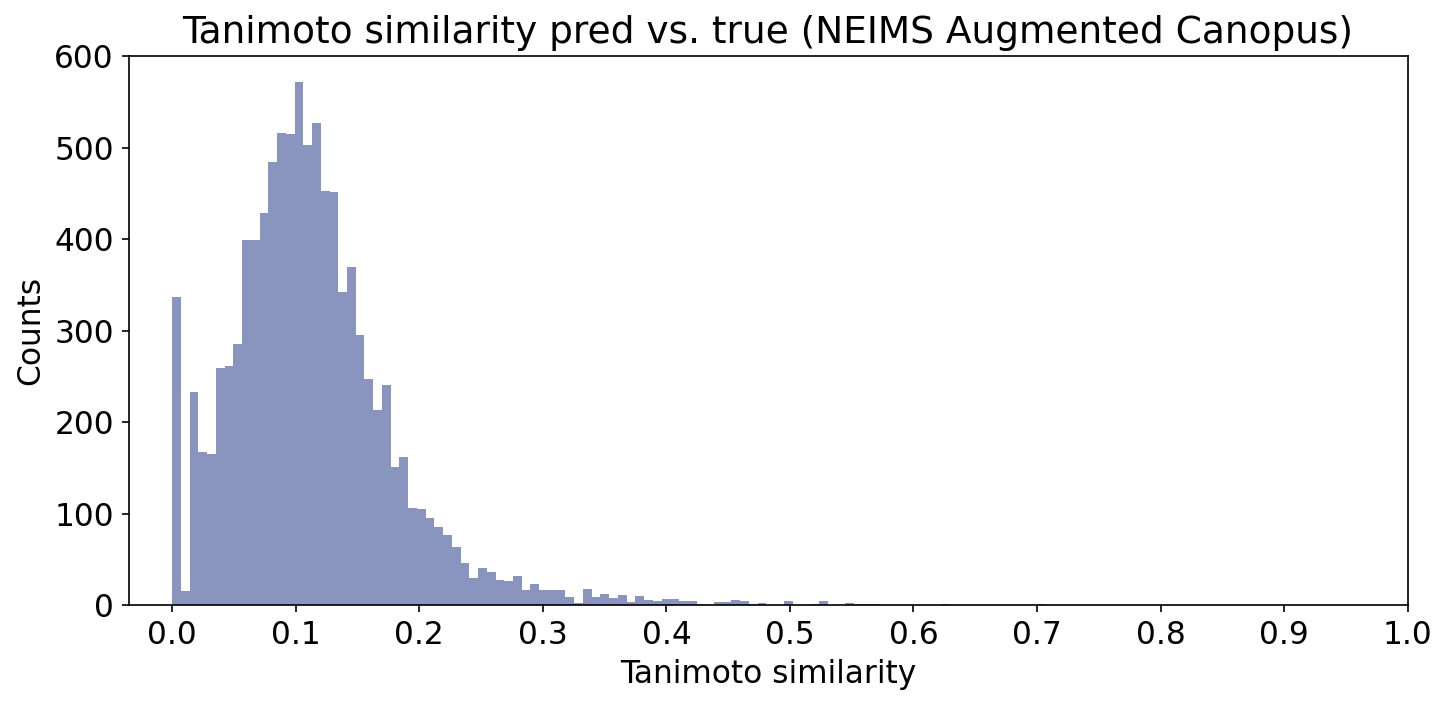

In [ ]:
valid_sims = [sim for sim in similarities if sim is not None]
print(f'{len(valid_sims)} valid similarities')
print(f"Mean Tanimoto similarity: {np.mean(valid_sims):.3f}")
print(f"Median Tanimoto similarity: {np.median(valid_sims):.3f}")
plt.figure(figsize=(1.1*9,1.1*4.5), dpi=150)
plt.hist(valid_sims, bins=100, color='#8995BF')
plt.title('Tanimoto similarity pred vs. true (NEIMS Augmented Canopus)')
plt.xlabel('Tanimoto similarity')
plt.ylabel('Counts')
plt.xticks(np.linspace(0, 1.0, 11))
plt.tight_layout()
plt.show()